# does the earlier result replicate across more seasons?

this frozen central park/KXHIGHNY replication runs from june 2025 through june 2026. june–december is development training, january–march is validation, and april–june is the later holdout. the 12-hour and 6-hour checkpoints stay paired to the same station-day outcome.

inputs are retained historical source reconstructions. the notebook checks target continuity before reading model results. if the central park/NWS definition or required coverage fails, it reports the failure and skips score interpretation.

In [1]:
import hashlib
import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

root = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "pyproject.toml").is_file()
)
plt.style.use(root / "config/styles/custom_qb_dark_darien.mplstyle")
run_dir = root / "outputs/historical-replication"
protocol_path = root / "config/replication-protocol.json"
panel_candidates = [
    run_dir / "combined-panel.json",
    run_dir / "panel.json",
    run_dir / "analysis/combined-panel.json",
]
panel_paths = []
for path in panel_candidates:
    if path.is_file():
        panel_paths.append(path)
assert len(panel_paths) == 1, f"expected one combined replication panel, found {panel_paths}"
panel_path = panel_paths[0]
results_path = run_dir / "analysis/historical-results.json"

protocol_bytes = protocol_path.read_bytes()
protocol = json.loads(protocol_bytes)
panel = json.loads(panel_path.read_bytes())


def semantic_sha256(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, allow_nan=False).encode()).hexdigest()


protocol_file_sha256 = hashlib.sha256(protocol_bytes).hexdigest()
assert protocol_file_sha256 == "f38377221e332dc78358e38d28dbc60e52225521ca4bac11b426d0a839a2cd33"
assert protocol["schema_version"] == "historical_replication_v1"
assert panel.get("schema_version") == "historical_panel_v1"
assert panel.get("replication_schema_version") == "historical_replication_panel_v1"
assert panel.get("data_origin") == "empirical_historical"
target_gate = panel.get("target_continuity", {})
assert isinstance(target_gate, dict), "combined panel must record target_continuity."
analysis_ready = target_gate.get("analysis_ready") is True
if analysis_ready:
    assert results_path.is_file(), "passed gate requires the saved evaluation."
    results = json.loads(results_path.read_bytes())
    assert results["schema_version"] == "historical_replication_evaluation_v1"
    assert results["data_origin"] == "empirical_historical"
    assert results["input_panel_sha256"] == semantic_sha256(panel)
    assert results["input_protocol_sha256"] == semantic_sha256(protocol)
else:
    assert not results_path.exists(), (
        "a failed target gate must not leave a fitted result at this run path."
    )
    results = None

print(
    {
        "panel": str(panel_path.relative_to(root)),
        "protocol_sha256": protocol_file_sha256,
        "analysis_ready": analysis_ready,
    }
)

{'panel': 'outputs/historical-replication/panel.json', 'protocol_sha256': 'f38377221e332dc78358e38d28dbc60e52225521ca4bac11b426d0a839a2cd33', 'analysis_ready': True}


## frozen question, split, and information policy

the extension was specified before opening the new holdout outcomes. p0 preserves the pooled-bias normal baseline. p1 adds only a 6-hour indicator, training-standardized maxt, and an annual sine/cosine pair, with ridge penalties fixed to 0.1, 1, or 10. the table below is read from the frozen protocol rather than reconstructed from the results.

In [2]:
collection = protocol["collection"]
freeze_rows = pd.DataFrame(
    [
        {"item": "cohort", "value": f"{collection['start_date']} through {collection['end_date']}"},
        {"item": "training", "value": f"through {collection['train_end_date']}"},
        {"item": "validation", "value": f"through {collection['validation_end_date']}"},
        {
            "item": "holdout",
            "value": (
                f"{pd.Timestamp(collection['validation_end_date']) + pd.Timedelta(days=1):%Y-%m-%d}"
                " onward"
            ),
        },
        {"item": "validation model cutoff", "value": protocol["validation_fit_at"]},
        {"item": "final development cutoff", "value": protocol["final_fit_at"]},
        {"item": "candidate order", "value": ", ".join(protocol["models"]["candidates"])},
        {
            "item": "oof months",
            "value": f"{protocol['oof']['start_month']} through {protocol['oof']['end_month']}",
        },
        {
            "item": "bootstrap",
            "value": (
                f"{protocol['bootstrap']['attempts']} attempts; "
                f"{protocol['bootstrap']['block_days']}-day primary blocks"
            ),
        },
    ]
)
display(freeze_rows)
display(
    Markdown(
        f"**Origin:** `{panel['data_origin']}`. **analysis class:** `{protocol['analysis_class']}`."
    )
)

,item,value
0,cohort,2025-06-01 through 2026-06-30
1,training,through 2025-12-31
2,validation,through 2026-03-31
3,holdout,2026-04-01 onward
4,validation model cutoff,2025-12-31T17:00:00+00:00
5,final development cutoff,2026-03-31T17:00:00+00:00
6,candidate order,"p0, p1_lambda_0.1, p1_lambda_1, p1_lambda_10"
7,oof months,2025-07-01 through 2026-03-01
8,bootstrap,5000 attempts; 7-day primary blocks


**Origin:** `empirical_historical`. **analysis class:** `exploratory_historical_replication`.

## target continuity is a gate, not a model choice

every requested event must retain the frozen central park/nws daily climate-report definition. a current series page, a matching ticker prefix, or a few sampled dates is not enough. this section is shown even when the gate fails.

In [3]:
display(pd.json_normalize([target_gate], sep=".").T.rename(columns={0: "recorded value"}))
target_inventory = pd.DataFrame(panel.get("target_inventory", []))
replication_inventory = pd.DataFrame(panel.get("replication_inventory", []))
expected_target_dates = len(
    pd.date_range(collection["start_date"], collection["end_date"], freq="D")
)
assert len(target_inventory) == expected_target_dates
assert len(replication_inventory) == expected_target_dates * len(collection["horizon_hours"])
display(
    target_inventory.groupby(["status", "settlement_label_status"], dropna=False)
    .size()
    .rename("dates")
    .to_frame()
)
display(target_inventory.loc[target_inventory["status"] != "compatible"].head(30))
reason_labels = {
    "could not convert string to float: ''": "missing numeric settlement label"
}
display_inventory = replication_inventory.assign(
    reason=replication_inventory["reason"].replace(reason_labels)
)
display(
    display_inventory.groupby(["status", "reason", "target_status"], dropna=False)
    .size()
    .rename("slots")
    .to_frame()
)

if analysis_ready:
    display(
        Markdown(
            "the recorded target-continuity gate passed. "
            "model sections below use the frozen cohort."
        )
    )
else:
    display(
        Markdown(
            "the recorded target-continuity gate did not pass. all model fitting, scores, "
            "uncertainty, and sensitivities below are skipped. this is the study result "
            "for this frozen cohort."
        )
    )

,recorded value
analysis_ready,True
incompatible_dates,[]
missing_slots,0
unverified_dates,[]


dates
status     settlement_label_status       
compatible present                    326
           unavailable                 69

,event_id,outcome_date,reason,rules_source_sha256,settlement_label_reason,settlement_label_status,status


,,,slots
status,reason,target_status,
case,NaN,compatible,652
excluded,missing numeric settlement label,compatible,138


the recorded target-continuity gate passed. model sections below use the frozen cohort.

## raw cohort inventory and coverage

the engineering row count is not the sample size. one event is one date and has up to two horizon cases. missing cases stay visible through the exclusion inventory.

In [4]:
raw_cases = panel.get("cases", [])
case_columns = [
    "case_id",
    "event_id",
    "outcome_date",
    "horizon_hours",
    "as_of_at",
    "outcome_window_start_at",
    "outcome_window_end_at",
    "forecast_available_at",
    "outcome_available_at",
    "forecast_f",
    "outcome_f",
    "ncei_tmax_f",
    "ncei_matches_settlement",
]
cases = pd.DataFrame(
    [{key: row.get(key) for key in case_columns} for row in raw_cases], columns=case_columns
)
if not cases.empty:
    cases["outcome_date"] = pd.to_datetime(cases["outcome_date"])
first = pd.Timestamp(collection["start_date"])
last = pd.Timestamp(collection["end_date"])
expected_dates = pd.date_range(first, last, freq="D")
expected_grid = pd.MultiIndex.from_product(
    [expected_dates, sorted(collection["horizon_hours"])], names=["outcome_date", "horizon_hours"]
)
observed_grid = pd.MultiIndex.from_frame(cases[["outcome_date", "horizon_hours"]])
missing_grid = expected_grid.difference(observed_grid)
coverage = pd.DataFrame(
    [
        {"measure": "requested dates", "count": len(expected_dates)},
        {"measure": "potential date-horizon cases", "count": len(expected_grid)},
        {"measure": "retained cases", "count": len(cases)},
        {
            "measure": "retained events",
            "count": cases["event_id"].nunique() if not cases.empty else 0,
        },
        {
            "measure": "retained dates",
            "count": cases["outcome_date"].nunique() if not cases.empty else 0,
        },
        {"measure": "non-case date-horizon slots", "count": len(missing_grid)},
        {
            "measure": "inventory missing slots",
            "count": int((replication_inventory["status"] == "missing").sum()),
        },
    ]
)
display(coverage)
monthly_inventory = replication_inventory.assign(
    month=replication_inventory["outcome_date"].str[:7]
)
monthly_slot_coverage = (
    monthly_inventory.groupby(["month", "status"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["case", "excluded", "missing"], fill_value=0)
    .rename(
        columns={
            "case": "retained_slots",
            "excluded": "excluded_slots",
            "missing": "unrecorded_slots",
        }
    )
)
monthly_slot_coverage.insert(0, "requested_slots", monthly_slot_coverage.sum(axis=1))
monthly_slot_coverage.index.name = "month (counts are date-horizon slots)"
display(monthly_slot_coverage)
display(pd.DataFrame(missing_grid.tolist(), columns=missing_grid.names).head(20))
assert int((replication_inventory["status"] == "case").sum()) == len(cases)

,measure,count
0,requested dates,395
1,potential date-horizon cases,790
2,retained cases,652
3,retained events,326
4,retained dates,326
5,non-case date-horizon slots,138
6,inventory missing slots,0


status,requested_slots,retained_slots,excluded_slots,unrecorded_slots
month (counts are date-horizon slots),,,,
2025-06,60,60,0,0
2025-07,62,62,0,0
2025-08,62,62,0,0
2025-09,60,60,0,0
2025-10,62,60,2,0
2025-11,60,8,52,0
2025-12,62,4,58,0
2026-01,62,38,24,0
2026-02,56,56,0,0


,outcome_date,horizon_hours
0,2025-10-31,6
1,2025-10-31,12
2,2025-11-01,6
3,2025-11-01,12
4,2025-11-02,6
5,2025-11-02,12
6,2025-11-03,6
7,2025-11-03,12
8,2025-11-04,6
9,2025-11-04,12


,cases
reason,
missing numeric settlement label,138


reason,missing numeric settlement label
month,
2025-10,2
2025-11,52
2025-12,58
2026-01,24
2026-06,2


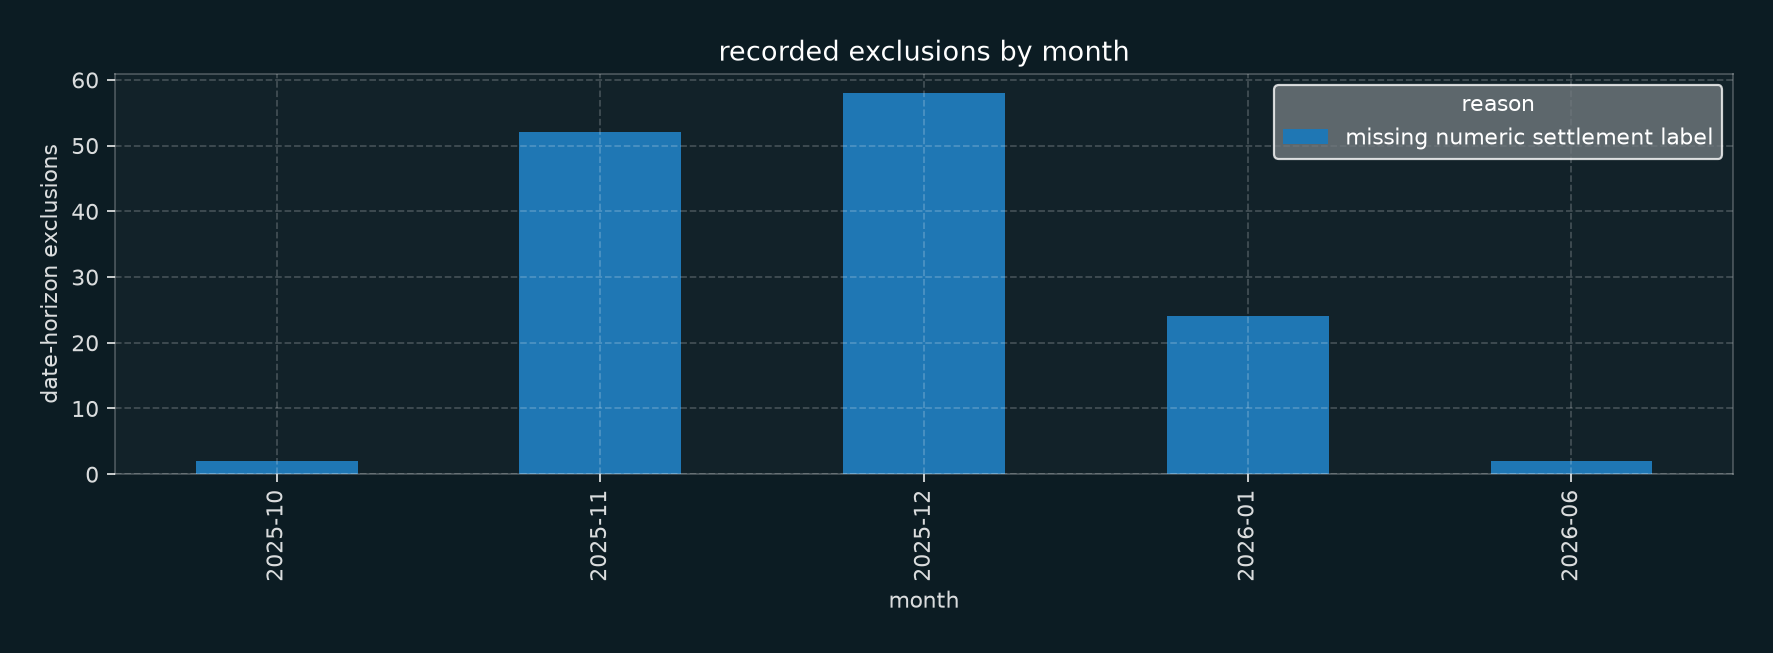

In [5]:
exclusions = pd.DataFrame(panel.get("exclusions", []))
if exclusions.empty:
    print("no exclusions were recorded.")
else:
    display_exclusions = exclusions.assign(reason=exclusions["reason"].replace(reason_labels))
    exclusion_counts = (
        display_exclusions.groupby(["reason"], dropna=False)
        .size()
        .rename("cases")
        .sort_values(ascending=False)
    )
    display(exclusion_counts.to_frame())
    if "outcome_date" in display_exclusions:
        by_month = (
            display_exclusions.assign(
                month=display_exclusions["outcome_date"].astype(str).str[:7]
            )
            .groupby(["month", "reason"])
            .size()
            .unstack(fill_value=0)
        )
        display(by_month)
        by_month.plot(
            kind="bar", stacked=True, figsize=(11, 4), title="recorded exclusions by month"
        )
        plt.ylabel("date-horizon exclusions")
        plt.tight_layout(pad=1.5)
        plt.show()

## sql audit: uniqueness and matched methods

sqlite keeps the audit close to the data. the first two queries test natural-key uniqueness in the combined panel. when the target gate passes, the method table also verifies that all five methods score the same cases rather than benefiting from different missingness.

In [6]:
connection = sqlite3.connect(":memory:")
sql_cases = cases.copy()
if not sql_cases.empty:
    sql_cases["outcome_date"] = sql_cases["outcome_date"].dt.strftime("%Y-%m-%d")
connection.execute("""CREATE TABLE cases (
    case_id TEXT, event_id TEXT, outcome_date TEXT, horizon_hours INTEGER,
    as_of_at TEXT, outcome_window_start_at TEXT, outcome_window_end_at TEXT,
    forecast_available_at TEXT, outcome_available_at TEXT, forecast_f REAL,
    outcome_f REAL, ncei_tmax_f REAL, ncei_matches_settlement INTEGER
)""")
if not sql_cases.empty:
    sql_cases.to_sql("cases", connection, index=False, if_exists="append")
duplicate_cases = pd.read_sql_query(
    "select case_id, count(*) as n from cases group by case_id having count(*) <> 1", connection
)
duplicate_event_horizons = pd.read_sql_query(
    """SELECT event_id, horizon_hours, COUNT(*) AS n
       FROM cases GROUP BY event_id, horizon_hours HAVING COUNT(*) <> 1""",
    connection,
)
display(
    {
        "duplicate_case_ids": len(duplicate_cases),
        "duplicate_event_horizons": len(duplicate_event_horizons),
    }
)
assert duplicate_cases.empty and duplicate_event_horizons.empty

if analysis_ready:
    score_rows = []
    for row in results["case_results"]:
        for method, metrics in row["scores"].items():
            score_rows.append(
                {
                    "case_id": row["case_id"],
                    "event_id": row["event_id"],
                    "outcome_date": row["outcome_date"],
                    "horizon_hours": row["horizon_hours"],
                    "split": row["split"],
                    "method": method,
                    **metrics,
                }
            )
    scores = pd.DataFrame(score_rows)
    scores.to_sql("scores", connection, index=False, if_exists="replace")
    method_audit = pd.read_sql_query(
        """SELECT split, horizon_hours, method, COUNT(DISTINCT case_id) AS cases,
                  COUNT(DISTINCT outcome_date) AS dates
           FROM scores GROUP BY split, horizon_hours, method
           ORDER BY split, horizon_hours, method""",
        connection,
    )
    unmatched = pd.read_sql_query(
        """SELECT case_id, COUNT(DISTINCT method) AS methods
           FROM scores GROUP BY case_id HAVING COUNT(DISTINCT method) <> 5""",
        connection,
    )
    display(method_audit)
    assert unmatched.empty
else:
    scores = pd.DataFrame()
    print("matched-method audit skipped because the target gate failed before evaluation.")

{'duplicate_case_ids': 0, 'duplicate_event_horizons': 0}

,split,horizon_hours,method,cases,dates
0,holdout,6,equal_blend,90,90
1,holdout,6,market_only,90,90
2,holdout,6,p0_reference,90,90
3,holdout,6,public_only,90,90
4,holdout,6,trained_blend,90,90
5,holdout,12,equal_blend,90,90
6,holdout,12,market_only,90,90
7,holdout,12,p0_reference,90,90
8,holdout,12,public_only,90,90
9,holdout,12,trained_blend,90,90


## forecast issue, availability, validity, and target windows

the forecast issue time, reconstructed availability bound, ndfd daytime validity, prediction checkpoint, and settlement-day window are distinct. archive timestamps bound historical availability; they do not prove local receipt or rule publication to a trader.

In [7]:
timing_rows = []
for row in raw_cases:
    forecast = row.get("forecast", {})
    timing_rows.append(
        {
            "case_id": row.get("case_id"),
            "outcome_date": row.get("outcome_date"),
            "horizon_hours": row.get("horizon_hours"),
            "as_of_at": row.get("as_of_at"),
            "forecast_issued_at": forecast.get("issued_at"),
            "forecast_available_at": row.get("forecast_available_at"),
            "forecast_valid_start_at": forecast.get("valid_start_at"),
            "forecast_valid_end_at": forecast.get("valid_end_at"),
            "outcome_window_start_at": row.get("outcome_window_start_at"),
            "outcome_window_end_at": row.get("outcome_window_end_at"),
            "outcome_available_at": row.get("outcome_available_at"),
            "availability_basis": forecast.get("availability_basis"),
        }
    )
timing = pd.DataFrame(timing_rows)
timestamp_columns = []
for column in timing:
    if column.endswith('_at'):
        timestamp_columns.append(column)
for column in timestamp_columns:
    timing[column] = pd.to_datetime(timing[column], utc=True, errors="coerce")
if not timing.empty:
    timing["forecast_age_minutes"] = (
        timing["as_of_at"] - timing["forecast_available_at"]
    ).dt.total_seconds() / 60
    timing["issue_to_availability_minutes"] = (
        timing["forecast_available_at"] - timing["forecast_issued_at"]
    ).dt.total_seconds() / 60
    timing["forecast_valid_hours"] = (
        timing["forecast_valid_end_at"] - timing["forecast_valid_start_at"]
    ).dt.total_seconds() / 3600
    timing["target_window_hours"] = (
        timing["outcome_window_end_at"] - timing["outcome_window_start_at"]
    ).dt.total_seconds() / 3600
    display(
        timing.groupby("horizon_hours")[
            [
                "forecast_age_minutes",
                "issue_to_availability_minutes",
                "forecast_valid_hours",
                "target_window_hours",
            ]
        ]
        .describe()
        .round(2)
    )
    assert (timing["forecast_available_at"] <= timing["as_of_at"]).all()
    assert (timing["forecast_valid_hours"] == collection["forecast_valid_hours"]).all()
    assert (timing["target_window_hours"] == 24).all()

forecast_age_minutes                                             \
                             count   mean   std   min   25%   50%   75%   max   
horizon_hours                                                                   
6                            326.0  14.10  1.61  14.0  14.0  14.0  14.0  43.0   
12                           326.0  14.18  3.32  14.0  14.0  14.0  14.0  74.0   

              issue_to_availability_minutes        ... forecast_valid_hours  \
                                      count  mean  ...                  75%   
horizon_hours                                      ...                        
6                                     326.0  16.0  ...                 12.0   
12                                    326.0  16.0  ...                 12.0   

                    target_window_hours                                     \
                max               count  mean  std   min   25%   50%   75%   
horizon_hours                                                                
6              12.0               326.0  24.0  0.0  24.0  24.0  24.0  24.0   
12             12.0               326.0  24.0  0.0  24.0  24.0  24.0  24.0   

                     
                max  
horizon_hours        
6              24.0  
12             24.0  

[2 rows x 32 columns]

## settlement and ncei reconciliation

ncei tmax is an independent check, not the label definition and not an eligibility filter. one event appears once below even though it has two horizon cases. disagreements remain visible.

In [8]:
events = (
    cases.sort_values(["outcome_date", "horizon_hours"]).drop_duplicates("event_id").copy()
    if not cases.empty
    else pd.DataFrame()
)
if not events.empty:
    events["ncei_minus_settlement_f"] = events["ncei_tmax_f"] - events["outcome_f"]
    reconciliation = (
        events["ncei_minus_settlement_f"].value_counts(dropna=False).sort_index().rename("events")
    )
    display(reconciliation.to_frame())
    display(
        events.loc[
            events["ncei_minus_settlement_f"].fillna(0) != 0,
            ["event_id", "outcome_date", "outcome_f", "ncei_tmax_f", "ncei_minus_settlement_f"],
        ]
    )
    monthly_reconciliation = (
        events.assign(month=events["outcome_date"].dt.to_period("M").astype(str))
        .groupby("month")["ncei_minus_settlement_f"]
        .agg(["count", "mean", "min", "max"])
    )
    display(monthly_reconciliation)
else:
    print("no retained events were available for ncei reconciliation.")

,events
ncei_minus_settlement_f,
0.0,325
5.0,1


,event_id,outcome_date,outcome_f,ncei_tmax_f,ncei_minus_settlement_f
2,KXHIGHNY-25JUN02,2025-06-02,66.0,71.0,5.0


,count,mean,min,max
month,,,,
2025-06,30,0.166667,0.0,5.0
2025-07,31,0.000000,0.0,0.0
2025-08,31,0.000000,0.0,0.0
2025-09,30,0.000000,0.0,0.0
2025-10,30,0.000000,0.0,0.0
2025-11,4,0.000000,0.0,0.0
2025-12,2,0.000000,0.0,0.0
2026-01,19,0.000000,0.0,0.0
2026-02,28,0.000000,0.0,0.0


## training residuals across date, horizon, and season

this section is descriptive and only runs after the target gate passes. the residual is settlement high minus daytime ndfd maxt. p1 calibrates that existing predictor; it does not add missing overnight weather information.

count   mean    std   min    max
season horizon_hours                                  
fall   6                 64  0.526  1.891 -3.01   7.07
       12                64  0.391  1.996 -3.91   5.03
spring 6                 30  1.539  4.345 -5.93  12.03
       12                30  1.929  4.487 -5.93  10.95
summer 6                 92 -0.442  2.389 -8.03   5.97
       12                92 -0.322  2.491 -8.03   7.05
winter 6                 49  1.470  2.880 -5.95  10.07
       12                49  1.529  2.807 -5.05   8.99

horizon_hours,6,12
month,,
2025-06,-1.432,-1.204
2025-07,-0.169,0.202
2025-08,0.244,0.006
2025-09,0.410,0.134
2025-10,0.273,0.267
2025-11,3.300,3.255
2025-12,1.540,1.990
2026-01,1.017,1.652
2026-02,1.772,1.412


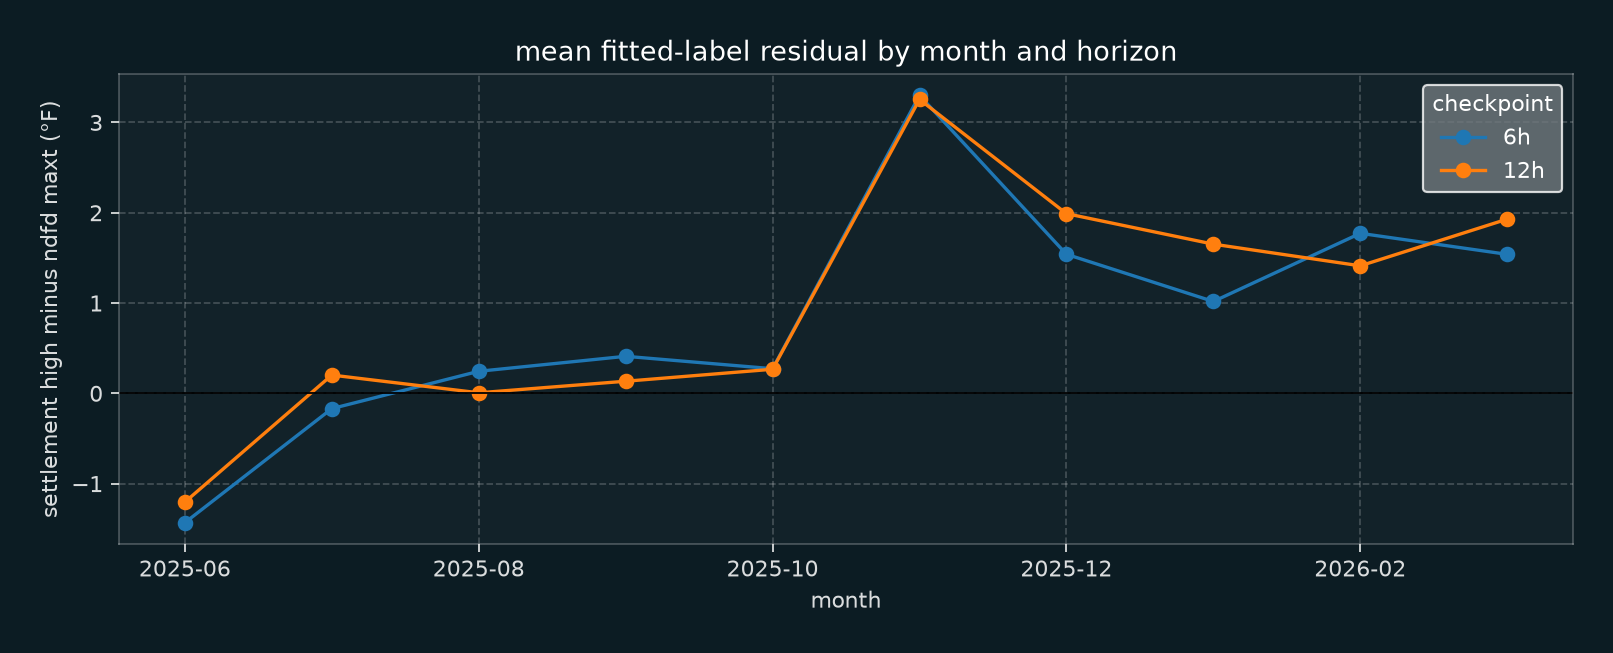

In [9]:
if analysis_ready:
    result_cases = pd.DataFrame(results["case_results"])
    result_cases["outcome_date"] = pd.to_datetime(result_cases["outcome_date"])
    result_cases["residual_f"] = result_cases["outcome_f"] - result_cases["forecast_f"]
    result_cases["month"] = result_cases["outcome_date"].dt.to_period("M").astype(str)
    result_cases["season"] = result_cases["outcome_date"].dt.month.map(
        {
            12: "winter",
            1: "winter",
            2: "winter",
            3: "spring",
            4: "spring",
            5: "spring",
            6: "summer",
            7: "summer",
            8: "summer",
            9: "fall",
            10: "fall",
            11: "fall",
        }
    )
    fitted_ids = set(results["fit"]["public_model"]["training_case_ids"])
    training = result_cases[result_cases["case_id"].isin(fitted_ids)].copy()
    display(
        training.groupby(["season", "horizon_hours"])["residual_f"]
        .agg(["count", "mean", "std", "min", "max"])
        .round(3)
    )
    monthly_residuals = training.groupby(["month", "horizon_hours"])["residual_f"].mean().unstack()
    display(monthly_residuals.round(3))
    plot_residuals = monthly_residuals.rename(columns=lambda horizon: f"{horizon}h")
    plot_residuals.columns.name = "checkpoint"
    plot_residuals.plot(
        marker="o", figsize=(10, 4), title="mean fitted-label residual by month and horizon"
    )
    plt.axhline(0, color="black", linewidth=.8)
    plt.ylabel("settlement high minus ndfd maxt (°F)")
    plt.tight_layout(pad=1.5)
    plt.show()
else:
    print("residual analysis skipped because the target gate failed.")

## candidate validation and chronological out-of-fold errors

candidate selection uses parameters frozen at the end of december and identical january–march cases. the july–march expanding-window records are the honest development predictions used for p1 error scales and the blend; final-refit validation summaries later in the notebook are in-sample and are not selection evidence.

,candidate,mean_validation_brier,cases,events,dates,fit_cutoff,ridge_lambda,coefficients,std_6h,std_12h
2,p1_lambda_1,0.813965,154,77,77,2025-12-31T17:00:00+00:00,1.0,"[-0.03834772419123669, -0.00405976338373254, -...",2.047659,2.192041
3,p1_lambda_10,0.823067,154,77,77,2025-12-31T17:00:00+00:00,10.0,"[-0.015658411836159306, -0.000498886704368158,...",2.073035,2.237963
0,p0,0.824413,154,77,77,2025-12-31T17:00:00+00:00,NaN,[-0.014303797468416972],2.275290,2.275290
1,p1_lambda_0.1,0.838248,154,77,77,2025-12-31T17:00:00+00:00,0.1,"[-0.1406416239610919, -0.01460159686516981, -0...",1.947898,2.088350


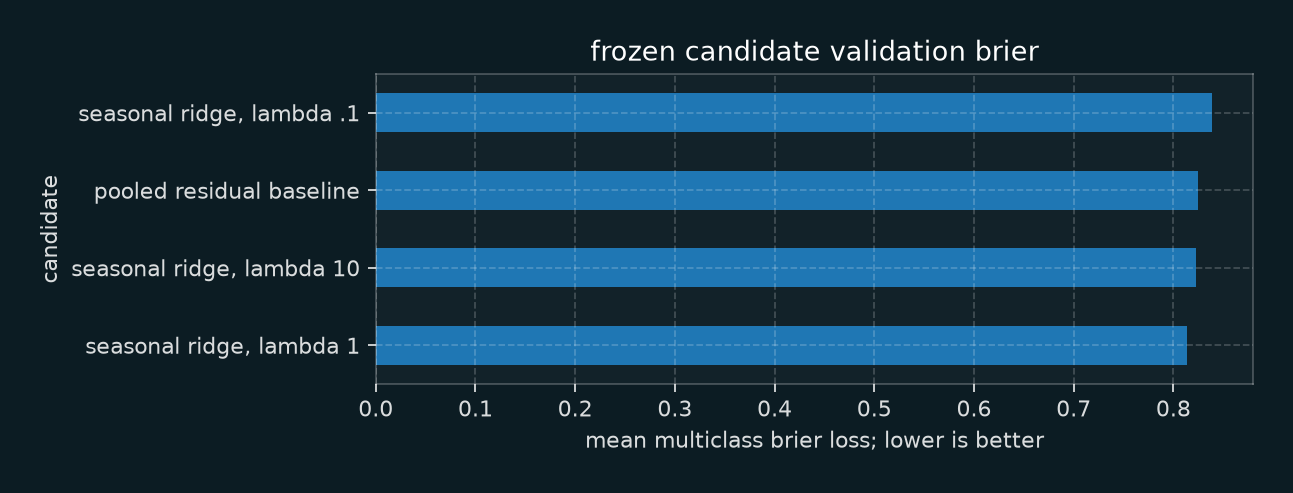

selected candidate: p1_lambda_1


In [10]:
if analysis_ready:
    candidate_rows = []
    for candidate in results["candidate_validation"]:
        fit_record = candidate["fit"]
        candidate_rows.append(
            {
                "candidate": candidate["candidate"],
                "mean_validation_brier": candidate["mean_brier"],
                "cases": candidate["cases"],
                "events": candidate["events"],
                "dates": candidate["dates"],
                "fit_cutoff": fit_record["cutoff_at"],
                "ridge_lambda": fit_record.get("ridge_lambda"),
                "coefficients": fit_record["coefficients"],
                "std_6h": candidate["predictive_std_by_horizon"].get("6"),
                "std_12h": candidate["predictive_std_by_horizon"].get("12"),
            }
        )
    candidate_validation = pd.DataFrame(candidate_rows).sort_values("mean_validation_brier")
    display(candidate_validation)
    candidate_labels = {
        "p0": "pooled residual baseline",
        "p1_lambda_0.1": "seasonal ridge, lambda .1",
        "p1_lambda_1": "seasonal ridge, lambda 1",
        "p1_lambda_10": "seasonal ridge, lambda 10",
    }
    plot_candidates = candidate_validation.assign(
        candidate_label=candidate_validation["candidate"].map(candidate_labels)
    )
    plot_candidates.set_index("candidate_label")["mean_validation_brier"].sort_values().plot(
        kind="barh", figsize=(8, 3), title="frozen candidate validation brier"
    )
    plt.ylabel("candidate")
    plt.xlabel("mean multiclass brier loss; lower is better")
    plt.tight_layout(pad=1.5)
    plt.show()
    print("selected candidate:", results["fit"]["selected_candidate"])
else:
    candidate_validation = pd.DataFrame()
    print("candidate validation skipped because the target gate failed.")

In [11]:
if analysis_ready:
    oof = pd.DataFrame(results["fit"]["oof"]["predictions"])
    oof["outcome_date"] = pd.to_datetime(oof["outcome_date"])
    oof["month"] = oof["outcome_date"].dt.to_period("M").astype(str)
    oof_summary = oof.groupby(["month", "horizon_hours"]).agg(
        cases=("case_id", "count"),
        mean_error_f=("error_f", "mean"),
        rms_error_f=("error_f", lambda values: float(np.sqrt(np.mean(np.square(values))))),
        probability_rows=("std_f", "count"),
        mean_std_f=("std_f", "mean"),
    )
    display(oof_summary.round(3))
    assert (
        oof.loc[
            oof["outcome_date"] < pd.Timestamp(protocol["oof"]["probabilities_start_month"]),
            "std_f",
        ]
        .isna()
        .all()
    )
    oof_fits = pd.DataFrame(
        [
            {
                "cutoff_at": fit["cutoff_at"],
                "spec": fit["spec"],
                "training_dates": len(fit["training_dates"]),
                "coefficients": fit["coefficients"],
            }
            for fit in results["fit"]["oof"]["fits"]
        ]
    )
    display(oof_fits)
else:
    oof = pd.DataFrame()
    print("chronological oof inspection skipped because the target gate failed.")

cases  mean_error_f  rms_error_f  probability_rows  \
month   horizon_hours                                                       
2025-07 6                 31         1.178        2.293                 0   
        12                31         1.492        2.801                 0   
2025-08 6                 31         0.966        1.806                31   
        12                31         0.664        1.708                31   
2025-09 6                 30         0.817        2.105                30   
        12                30         0.508        1.817                30   
2025-10 6                 30         0.552        1.677                30   
        12                30         0.541        1.986                30   
2025-11 6                  4         3.309        3.618                 4   
        12                 4         3.261        3.789                 4   
2025-12 6                  2         1.070        1.207                 2   
        12                 2         1.513        1.816                 2   
2026-01 6                 19         0.518        2.854                19   
        12                19         1.143        3.166                19   
2026-02 6                 28         1.232        3.199                28   
        12                28         0.860        2.870                28   
2026-03 6                 30         0.993        4.419                30   
        12                30         1.369        4.670                30   

                       mean_std_f  
month   horizon_hours              
2025-07 6                     NaN  
        12                    NaN  
2025-08 6                   1.907  
        12                  2.402  
2025-09 6                   2.068  
        12                  2.328  
2025-10 6                   2.089  
        12                  2.181  
2025-11 6                   1.986  
        12                  2.125  
2025-12 6                   2.058  
        12                  2.197  
2026-01 6                   2.048  
        12                  2.192  
2026-02 6                   2.176  
        12                  2.340  
2026-03 6                   2.317  
        12                  2.437

,cutoff_at,spec,training_dates,coefficients
0,2025-06-30T17:00:00+00:00,p1,29,"[-1.4367048280216494, -0.06294097828333586, 0...."
1,2025-07-31T17:00:00+00:00,p1,60,"[-0.750597647414923, -0.058962023815438046, 0...."
2,2025-08-31T17:00:00+00:00,p1,91,"[-0.42824769194995416, -0.024846351106572913, ..."
3,2025-09-30T17:00:00+00:00,p1,121,"[-0.2701360413127653, -0.004533619372934888, 0..."
4,2025-10-31T17:00:00+00:00,p1,152,"[-0.18655411360659446, -0.0033208226915651096,..."
5,2025-11-30T17:00:00+00:00,p1,156,"[-0.06857935570239433, -0.0029745511756382828,..."
6,2025-12-31T17:00:00+00:00,p1,158,"[-0.03834772419123669, -0.00405976338373254, -..."
7,2026-01-31T17:00:00+00:00,p1,176,"[0.14633450614219046, -0.014996443220378547, -..."
8,2026-02-28T17:00:00+00:00,p1,204,"[0.3519725500847636, -0.009940980992192875, -0..."


## five methods on validation and holdout

public-only, market-only, equal blend, trained blend, and the p0 reference use identical retained cases. holdout rows use the final model fixed by march 31. the displayed validation aggregate from the final refit is descriptive and in-sample; the candidate table above controls model selection.

,split,horizon_hours,cases,events,dates,method,brier,log_loss,prediction_role
0,validation,12,78,78,78,public_only,0.791836,1.718581,development_refit_in_sample
1,validation,12,78,78,78,market_only,0.724510,1.467060,development_refit_in_sample
2,validation,12,78,78,78,equal_blend,0.735703,1.513287,development_refit_in_sample
3,validation,12,78,78,78,trained_blend,0.724510,1.467060,development_refit_in_sample
4,validation,12,78,78,78,p0_reference,0.798537,1.745255,development_refit_in_sample
5,validation,6,78,78,78,public_only,0.796887,1.767228,development_refit_in_sample
6,validation,6,78,78,78,market_only,0.665740,1.313100,development_refit_in_sample
7,validation,6,78,78,78,equal_blend,0.704827,1.443000,development_refit_in_sample
8,validation,6,78,78,78,trained_blend,0.665740,1.313100,development_refit_in_sample
9,validation,6,78,78,78,p0_reference,0.802242,1.776318,development_refit_in_sample


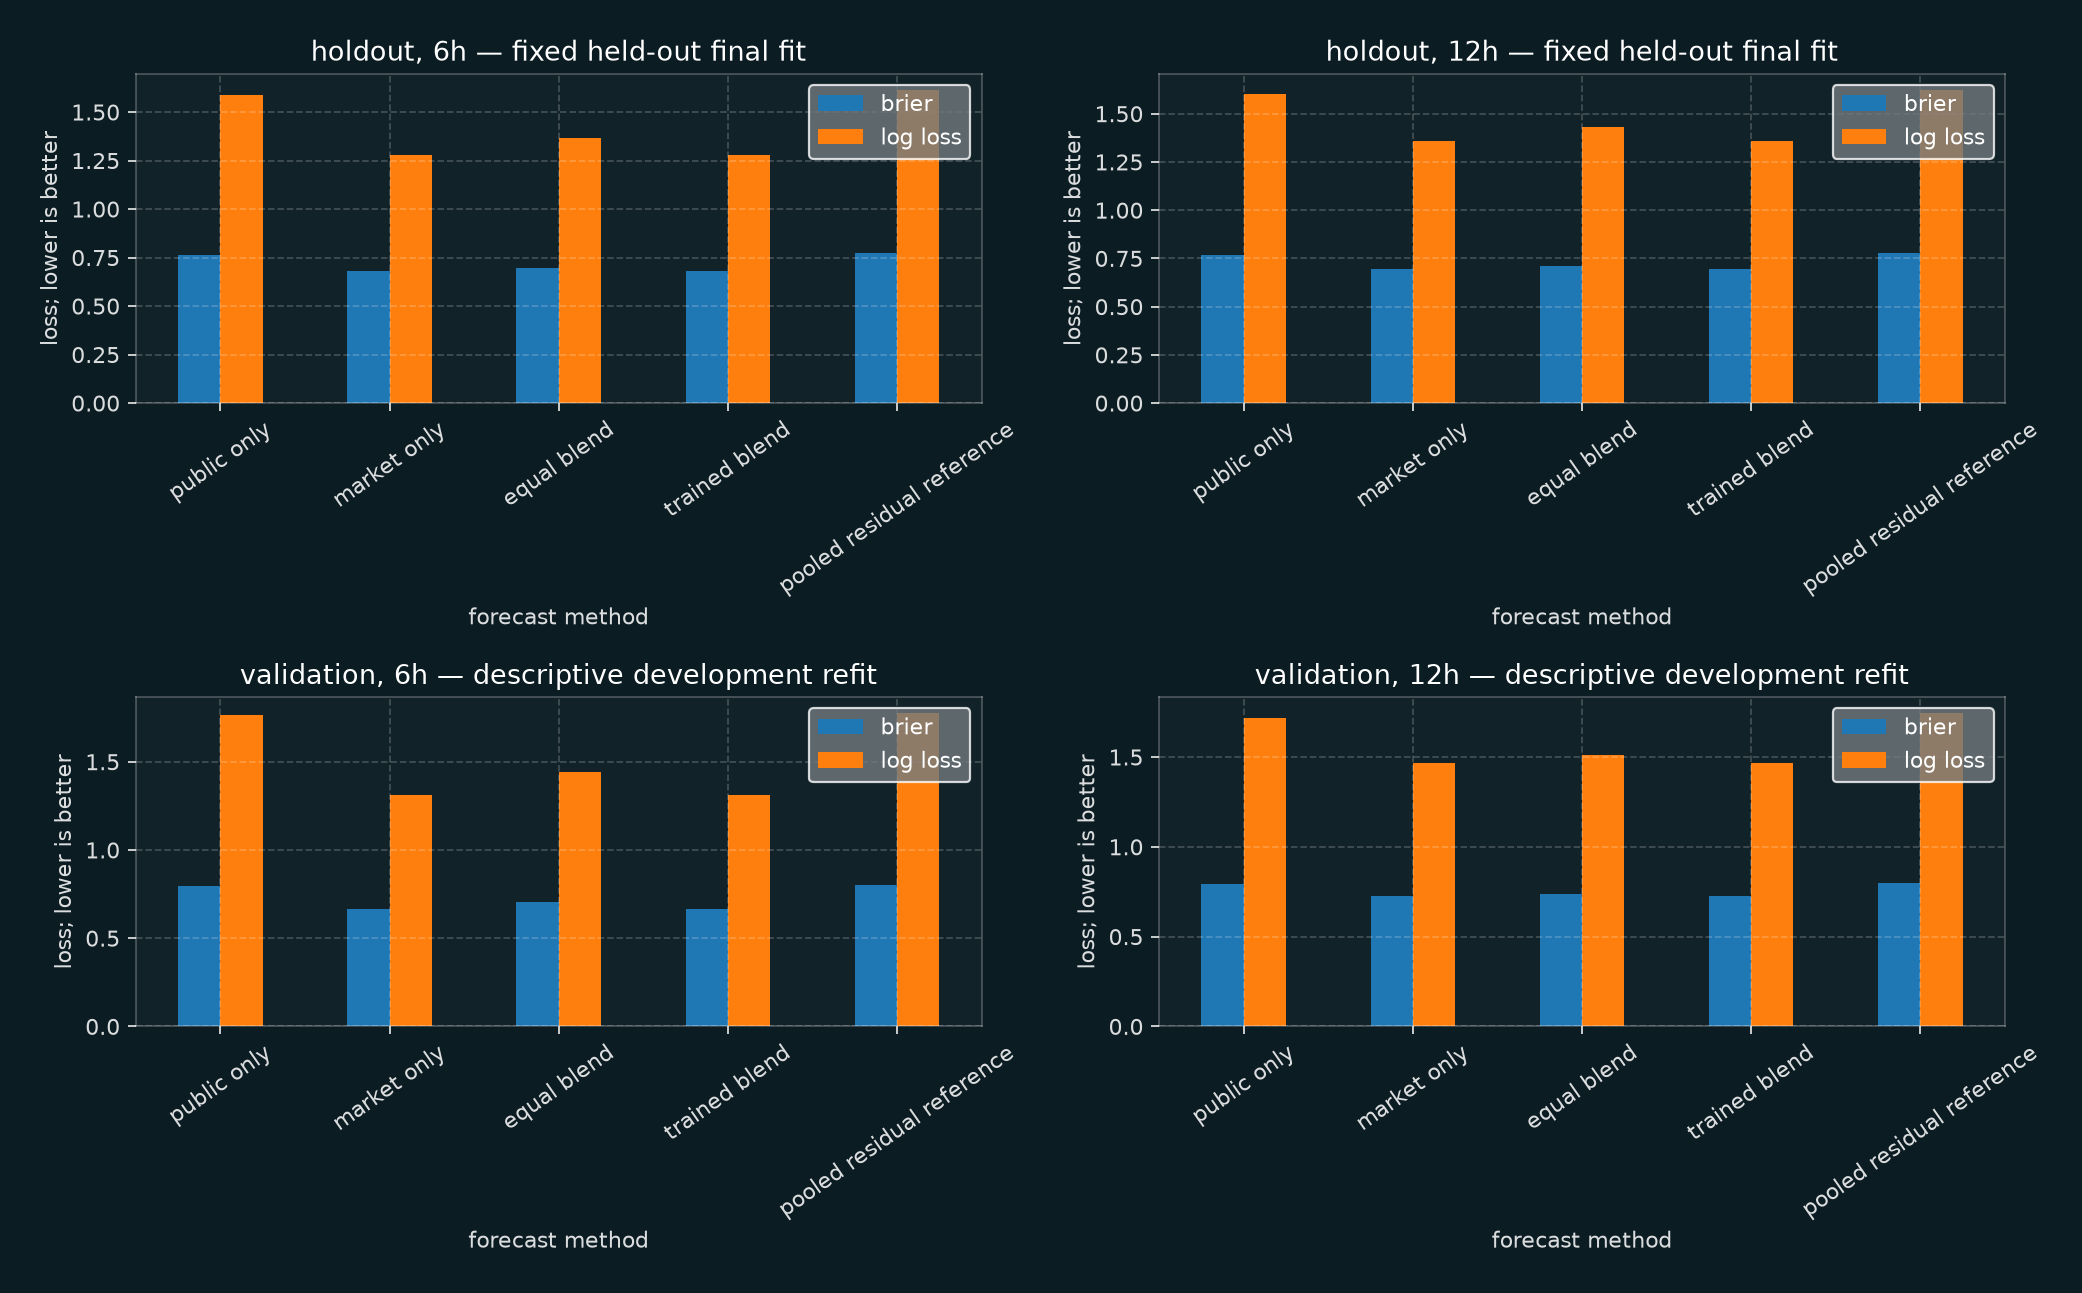

In [12]:
methods = protocol["metrics"]["required_methods"]
method_labels = {
    "public_only": "public only",
    "market_only": "market only",
    "equal_blend": "equal blend",
    "trained_blend": "trained blend",
    "p0_reference": "pooled residual reference",
}
prediction_role_labels = {
    "development_refit_in_sample": "descriptive development refit",
    "held_out_fixed_final_fit": "fixed held-out final fit",
}
if analysis_ready:
    summary_rows = []
    for summary in results["summaries"]:
        if summary["split"] not in ("validation", "holdout"):
            continue
        for method in methods:
            summary_rows.append(
                {
                    "split": summary["split"],
                    "horizon_hours": summary["horizon_hours"],
                    "cases": summary["cases"],
                    "events": summary["events"],
                    "dates": summary["dates"],
                    "method": method,
                    **summary["scores"][method],
                    "prediction_role": summary["prediction_role"],
                }
            )
    summary_scores = pd.DataFrame(summary_rows)
    display(summary_scores)
    _, axes = plt.subplots(2, 2, figsize=(13, 8))
    for axis, ((split, horizon), subset) in zip(
        axes.flat, summary_scores.groupby(["split", "horizon_hours"])
    ):
        plot_scores = subset.assign(method_label=subset["method"].map(method_labels))
        plot_scores = plot_scores.set_index("method_label")[["brier", "log_loss"]]
        plot_scores.rename(columns={"log_loss": "log loss"}).plot(kind="bar", ax=axis)
        role = prediction_role_labels[subset.iloc[0].prediction_role]
        axis.set_title(f"{split}, {horizon}h — {role}")
        axis.set_xlabel("forecast method")
        axis.set_ylabel("loss; lower is better")
        axis.tick_params(axis="x", rotation=35)
    plt.tight_layout(pad=1.5)
    plt.show()
else:
    summary_scores = pd.DataFrame()
    print("method scores skipped because the target gate failed.")

## descriptive holdout calibration

calibration bins pool contract-bin probabilities for display. bins from the same event are dependent, so these curves do not supply an independent-case significance test.

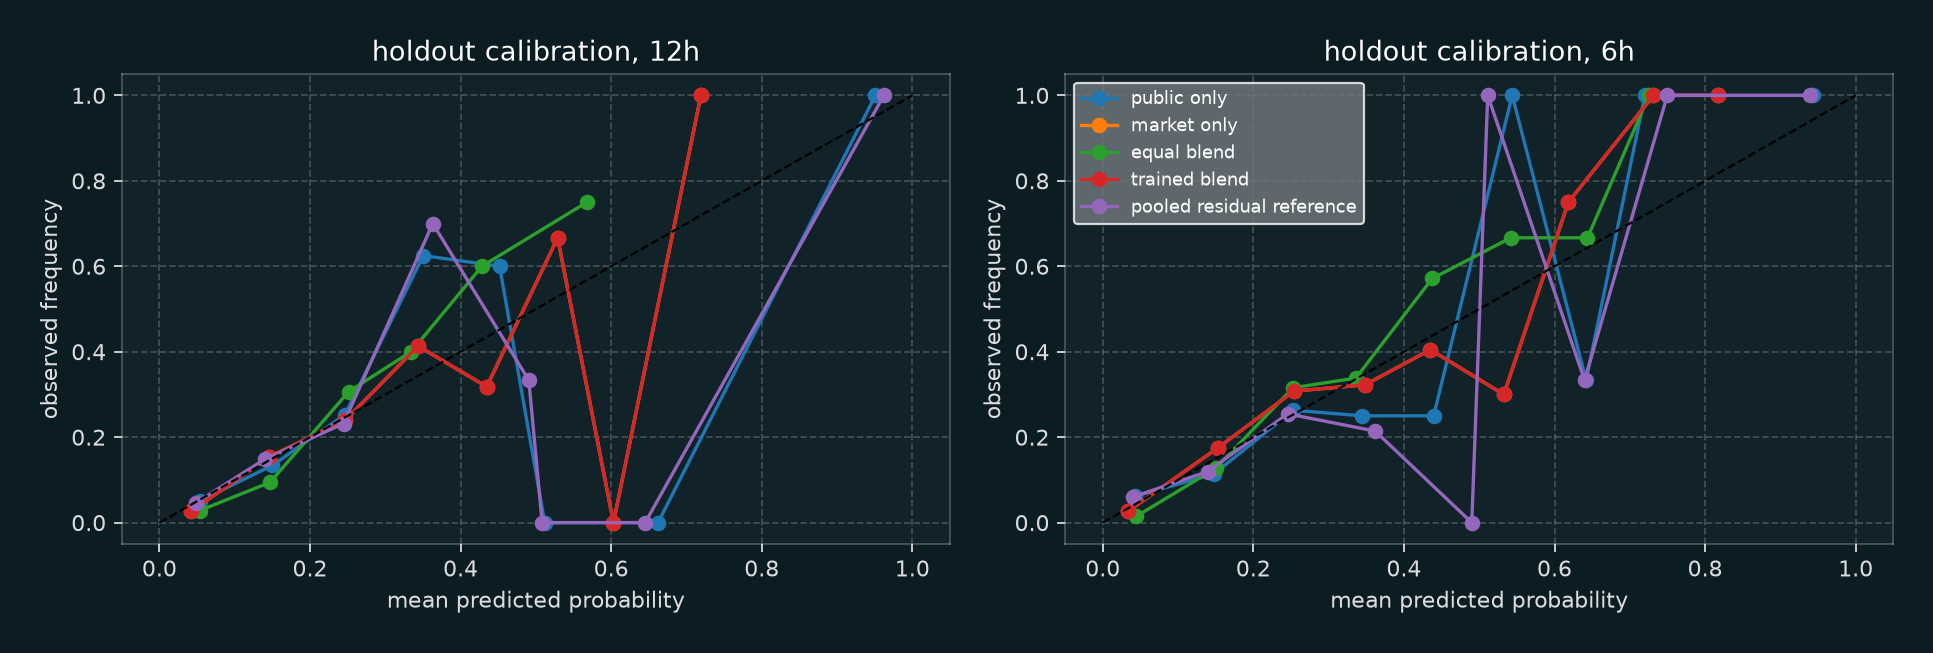

In [13]:
if analysis_ready:
    heldout = []
    for summary in results['summaries']:
        if summary['split'] == 'holdout':
            heldout.append(summary)
    _, axes = plt.subplots(1, len(heldout), figsize=(12, 4), squeeze=False)
    for axis, summary in zip(axes.flat, heldout, strict=True):
        for method in methods:
            bins = pd.DataFrame(summary["calibration"][method])
            observed = bins.dropna(subset=["mean_probability", "observed_frequency"])
            axis.plot(
                observed["mean_probability"],
                observed["observed_frequency"],
                marker="o",
                label=method_labels[method],
            )
        axis.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
        axis.set(
            title=f"holdout calibration, {summary['horizon_hours']}h",
            xlabel="mean predicted probability",
            ylabel="observed frequency",
        )
    axes.flat[-1].legend(fontsize=8)
    plt.tight_layout(pad=1.5)
    plt.show()
else:
    print("calibration skipped because the target gate failed.")

## paired uncertainty: full refits, fixed fit, and block length

the primary intervals repeat standardization, chronological folds, candidate selection, final fitting, out-of-fold scale estimation, blend fitting, condition thresholds, and holdout scoring. the fixed-fit result resamples holdout dates without refitting. three- and fourteen-day blocks are full-refit sensitivities. failed attempts are counted and never redrawn.

,bootstrap,block_days,horizon_hours,mean_difference,ci95,ci975,attempted,valid,failed,interval_unavailable_reason
4,full refit primary,7,12,-0.073856,"[-0.10487864173913461, -0.02559303436743874]","[-0.11028161504199774, -0.019122756680623267]",5000,5000,0,None
12,full refit primary,7,6,-0.080188,"[-0.11816266959773322, -0.015189276026782184]","[-0.12618928578567445, -0.007384474650285887]",5000,5000,0,None
20,fixed fit,7,12,-0.073856,"[-0.10295974976178322, -0.032586517696877516]","[-0.10780154449088994, -0.027381807914779403]",5000,5000,0,None
28,fixed fit,7,6,-0.080188,"[-0.11646375155506994, -0.02704438703848665]","[-0.12297331726651044, -0.02171369360199186]",5000,5000,0,None
36,full refit 14-day,14,12,-0.073856,"[-0.09605828814441579, -0.03706515219678874]","[-0.09957053511740571, -0.03295903377248623]",5000,5000,0,None
44,full refit 14-day,14,6,-0.080188,"[-0.10586851069265298, -0.028712019917951425]","[-0.11200047528033553, -0.023611603632401147]",5000,5000,0,None
52,full refit 3-day,3,12,-0.073856,"[-0.11496376944576625, -0.02219712749633842]","[-0.12138481713377584, -0.016110630264050966]",5000,5000,0,None
60,full refit 3-day,3,6,-0.080188,"[-0.13116536846385998, -0.016554837909022933]","[-0.13980524334341474, -0.00918324199575021]",5000,5000,0,None


,bootstrap,block_days,attempted,valid,failed,selection_counts,errors
0,full refit primary,7,5000,5000,0,"{'p0': 918, 'p1_lambda_0.1': 837, 'p1_lambda_1...",{}
1,fixed fit,7,5000,5000,0,{},{}
2,full refit 14-day,14,5000,5000,0,"{'p0': 1058, 'p1_lambda_0.1': 580, 'p1_lambda_...",{}
3,full refit 3-day,3,5000,5000,0,"{'p0': 908, 'p1_lambda_0.1': 865, 'p1_lambda_1...",{}


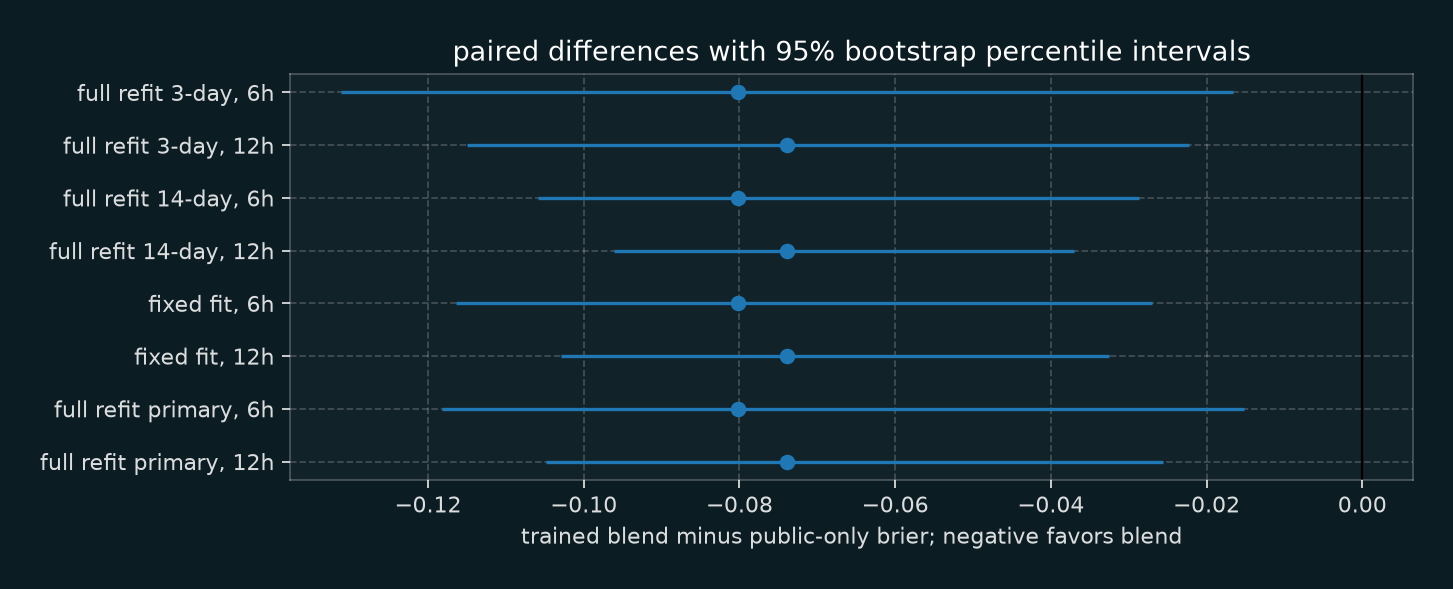

In [14]:
def comparison_frame(record, label):
    return pd.DataFrame(record["comparisons"]).assign(
        bootstrap=label,
        block_days=record["block_days"],
        attempted=record["attempted"],
        valid=record["valid"],
        failed=record["failed"],
    )


if analysis_ready:
    bootstrap = results["bootstrap"]
    bootstrap_records = [
        ("full refit primary", bootstrap["primary"]),
        ("fixed fit", bootstrap["fixed_fit"]),
    ]
    bootstrap_records.extend(
        (f"full refit {days}-day", record)
        for days, record in bootstrap["sensitivity_by_block_days"].items()
    )
    comparisons = pd.concat(
        [comparison_frame(record, label) for label, record in bootstrap_records], ignore_index=True
    )
    primary_intervals = comparisons[
        (comparisons["method"] == "trained_blend") & (comparisons["metric"] == "brier")
    ][
        [
            "bootstrap",
            "block_days",
            "horizon_hours",
            "mean_difference",
            "ci95",
            "ci975",
            "attempted",
            "valid",
            "failed",
            "interval_unavailable_reason",
        ]
    ]
    display(primary_intervals)
    diagnostics = pd.DataFrame(
        [
            {
                "bootstrap": label,
                "block_days": record["block_days"],
                "attempted": record["attempted"],
                "valid": record["valid"],
                "failed": record["failed"],
                "selection_counts": record["selection_counts"],
                "errors": record["errors"],
            }
            for label, record in bootstrap_records
        ]
    )
    display(diagnostics)
    plot_rows = primary_intervals.dropna(subset=["ci95"]).copy()
    if not plot_rows.empty:
        plot_rows["label"] = (
            plot_rows["bootstrap"] + ", " + plot_rows["horizon_hours"].astype(str) + "h"
        )
        centers = plot_rows["mean_difference"].to_numpy()
        lower = np.array([value[0] for value in plot_rows["ci95"]])
        upper = np.array([value[1] for value in plot_rows["ci95"]])
        plt.figure(figsize=(9, max(3, len(plot_rows) * .45)))
        positions = np.arange(len(plot_rows))
        plt.hlines(positions, lower, upper, linewidth=1.5)
        plt.scatter(centers, positions, zorder=3)
        plt.axvline(0, color="black", linewidth=1)
        plt.yticks(positions, plot_rows["label"])
        plt.title("paired differences with 95% bootstrap percentile intervals")
        plt.xlabel("trained blend minus public-only brier; negative favors blend")
        plt.tight_layout(pad=1.5)
        plt.show()
else:
    comparisons = pd.DataFrame()
    print("bootstrap uncertainty skipped because the target gate failed.")

## does disagreement identify when the blend helps?

the high/low threshold is the horizon-specific weighted median from august–march oof predictions. high means strictly above the threshold. the interaction is the direct high-minus-low difference in `trained blend − public-only` brier. each observed group needs 20 dates and five occupied nonoverlapping seven-day calendar blocks before an interval is shown.

In [15]:
if analysis_ready:
    condition_rows = []
    for condition in results["bootstrap"]["primary"]["conditions"]:
        horizon = condition["horizon_hours"]
        for group, group_record in condition["groups"].items():
            comparison = group_record["paired_comparisons"][0]
            condition_rows.append(
                {
                    "horizon_hours": horizon,
                    "row": group,
                    "dates": group_record["dates"],
                    "calendar_blocks": group_record["calendar_blocks"],
                    "supported": group_record["supported"],
                    "mean_difference": comparison["mean_difference"],
                    "ci95": comparison["ci95"],
                    "valid_replicates": comparison["valid_replicates"],
                    "reason": comparison["interval_unavailable_reason"],
                }
            )
        interaction = condition["interactions"][0]
        condition_rows.append(
            {
                "horizon_hours": horizon,
                "row": "high minus low",
                "dates": None,
                "calendar_blocks": None,
                "supported": condition["support"]["supported"],
                "mean_difference": interaction["mean_difference"],
                "ci95": interaction["ci95"],
                "valid_replicates": interaction["valid_replicates"],
                "reason": interaction["interval_unavailable_reason"],
            }
        )
    conditions = pd.DataFrame(condition_rows)
    display(
        pd.Series(
            results["fit"]["disagreement_l1_median_by_horizon"],
            name="oof weighted-median threshold",
        ).to_frame()
    )
    display(conditions)
else:
    conditions = pd.DataFrame()
    print("disagreement analysis skipped because the target gate failed.")

,oof weighted-median threshold
12,0.327452
6,0.397916


,horizon_hours,row,dates,calendar_blocks,supported,mean_difference,ci95,valid_replicates,reason
0,12,high,68.0,13.0,True,-0.087315,"[-0.1432850069932308, -0.03408211298552437]",5000,NaN
1,12,low,22.0,9.0,True,-0.032255,"[-0.051014433772455944, 0.034972438783763826]",5000,NaN
2,12,high minus low,NaN,NaN,True,-0.055060,"[-0.15821574200689947, -0.004677808693490472]",5000,NaN
3,6,high,73.0,13.0,True,-0.100104,None,5000,insufficient_original_condition_group_support
4,6,low,17.0,8.0,False,0.005333,None,5000,insufficient_original_condition_group_support
5,6,high minus low,NaN,NaN,False,-0.105437,None,5000,insufficient_original_condition_group_support


## prespecified sensitivities

the label sensitivity substitutes the independently recorded ncei value for june 2 in development only. the normalization sensitivity projects raw candle midpoints onto the simplex instead of proportional normalization. they remain point sensitivities and do not replace the primary result.

In [16]:
if analysis_ready:
    sensitivity_status = pd.DataFrame(
        [
            {
                "sensitivity": name,
                "status": record["status"],
                "reason": record.get("reason"),
                "changed_cases": len(record.get("changed_case_ids", [])),
            }
            for name, record in results["sensitivities"].items()
        ]
    )
    display(sensitivity_status)
    delta_rows = []
    for name, record in results["sensitivities"].items():
        for delta in record.get("holdout_deltas", []):
            delta_rows.append({"sensitivity": name, **delta})
    sensitivity_deltas = pd.DataFrame(delta_rows)
    if not sensitivity_deltas.empty:
        display(
            sensitivity_deltas.pivot_table(
                index=["sensitivity", "horizon_hours"],
                columns="method",
                values="brier_difference_from_primary",
            )
        )
else:
    sensitivity_status = pd.DataFrame()
    print("sensitivity evaluation skipped because the target gate failed.")

,sensitivity,status,reason,changed_cases
0,label_substitution,evaluated,None,2
1,normalization_projection,evaluated,None,652


method                                  equal_blend  market_only  \
sensitivity              horizon_hours                             
label_substitution       6                 0.000659     0.000000   
                         12                0.000516     0.000000   
normalization_projection 6                -0.001409     0.000348   
                         12               -0.001219    -0.002016   

method                                  p0_reference  public_only  \
sensitivity              horizon_hours                              
label_substitution       6                  0.001664     0.002106   
                         12                 0.001534     0.001570   
normalization_projection 6                  0.000000     0.000000   
                         12                 0.000000     0.000000   

method                                  trained_blend  
sensitivity              horizon_hours                 
label_substitution       6                   0.000000  
                         12                  0.000000  
normalization_projection 6                   0.000348  
                         12                 -0.002016

## what this run can support

a negative paired difference favors the named method for this frozen cohort. it does not establish market superiority elsewhere, a causal explanation, or trading profit. candle histories do not establish fills. archive timing and historical rules remain reconstructed. missing dates may select an easier or harder sample, especially when winter settlement labels are absent. p1 calibrates a daytime grid predictor to a full-day station target; it cannot remove that mismatch. the bootstrap holds month composition fixed, cuts dependence at month boundaries, and underweights month-edge dates, especially with 14-day blocks. its percentile intervals are approximate. condition groups remain descriptive when their support guard fails.

In [17]:
if analysis_ready:
    selected_candidate = results["fit"]["selected_candidate"]
    trained_market_weight = results["fit"]["trained_market_weight"]
    trained_is_market = all(
        row["probabilities"]["trained_blend"] == row["probabilities"]["market_only"]
        for row in results["case_results"]
    )
    condition_by_horizon = {}
    for row in results['bootstrap']['primary']['conditions']:
        condition_by_horizon[row['horizon_hours']] = row
    interaction_12h = condition_by_horizon[12]["interactions"][0]
    low_6h = condition_by_horizon[6]["groups"]["low"]
    assert selected_candidate == "p1_lambda_1"
    assert trained_market_weight == 1 and trained_is_market
    assert interaction_12h["ci95"][1] < 0
    assert interaction_12h["ci975"][0] <= 0 <= interaction_12h["ci975"][1]
    assert low_6h["dates"] == 17 and low_6h["supported"] is False
    display(
        Markdown(
            f"the selected model was **p1 with ridge lambda 1**. its fitted market "
            f"weight was **{trained_market_weight:.1f}**, making the trained blend "
            "identical to market-only on every scored case; this fit therefore showed "
            "no observed benefit from mixing the two probability vectors. at 12 hours, "
            f"the disagreement interaction's 95% interval ({interaction_12h['ci95'][0]:.3f}, "
            f"{interaction_12h['ci95'][1]:.3f}) excluded zero, while its 97.5% interval "
            f"({interaction_12h['ci975'][0]:.3f}, {interaction_12h['ci975'][1]:.3f}) "
            "included zero. the 6-hour low-disagreement group had 17 dates and failed "
            "the prespecified 20-date support requirement."
        )
    )
    for summary in results["summaries"]:
        if summary["split"] != "holdout":
            continue
        comparison = next(
            item
            for item in summary["paired_comparisons"]
            if item["method"] == "trained_blend" and item["metric"] == "brier"
        )
        print(
            {
                "horizon_hours": summary["horizon_hours"],
                "holdout_dates": summary["dates"],
                "trained_minus_public_brier": comparison["mean_difference"],
                "ci95": comparison["ci95"],
                "ci975": comparison["ci975"],
                "interval_unavailable_reason": comparison["interval_unavailable_reason"],
            }
        )
    display(
        Markdown(
            "interpret these numbers only with the scope limits above and the recorded "
            "target/coverage evidence."
        )
    )
else:
    display(
        Markdown(
            "no forecasting claim is available because the frozen target-continuity "
            "gate did not pass."
        )
    )

the selected model was **p1 with ridge lambda 1**. its fitted market weight was **1.0**, making the trained blend identical to market-only on every scored case; this fit therefore showed no observed benefit from mixing the two probability vectors. at 12 hours, the disagreement interaction's 95% interval (-0.158, -0.005) excluded zero, while its 97.5% interval (-0.168, 0.005) included zero. the 6-hour low-disagreement group had 17 dates and failed the prespecified 20-date support requirement.

{'horizon_hours': 12, 'holdout_dates': 90, 'trained_minus_public_brier': -0.07385630462588859, 'ci95': [-0.10487864173913461, -0.02559303436743874], 'ci975': [-0.11028161504199774, -0.019122756680623267], 'interval_unavailable_reason': None}
{'horizon_hours': 6, 'holdout_dates': 90, 'trained_minus_public_brier': -0.08018826686294801, 'ci95': [-0.11816266959773322, -0.015189276026782184], 'ci975': [-0.12618928578567445, -0.007384474650285887], 'interval_unavailable_reason': None}


interpret these numbers only with the scope limits above and the recorded target/coverage evidence.

## reproduction links and immutable inputs

the saved outputs below come from reading the frozen panel and result. execution does not collect data or refit models.

In [18]:
artifact_rows = [
    {
        "artifact": "frozen protocol",
        "path": str(protocol_path.relative_to(root)),
        "sha256": protocol_file_sha256,
    },
    {
        "artifact": "combined panel",
        "path": str(panel_path.relative_to(root)),
        "sha256": hashlib.sha256(panel_path.read_bytes()).hexdigest(),
    },
]
if analysis_ready:
    artifact_rows.append(
        {
            "artifact": "saved evaluation",
            "path": str(results_path.relative_to(root)),
            "sha256": hashlib.sha256(results_path.read_bytes()).hexdigest(),
        }
    )
display(pd.DataFrame(artifact_rows))
connection.close()

,artifact,path,sha256
0,frozen protocol,config/replication-protocol.json,f38377221e332dc78358e38d28dbc60e52225521ca4bac...
1,combined panel,outputs/historical-replication/panel.json,0388149dc4b04adccad1dff9fcb2cb96e84be79499b148...
2,saved evaluation,outputs/historical-replication/analysis/histor...,9f9a8ce0a96849300b8a054dfd23ab4b94c29d243ad2b5...
